In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /home/xtallet/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/xtallet/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [2]:
import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

In [4]:
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - AdvancedBuild - {uuid4().hex[0:8]}"

In [5]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

In [50]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()
docs = docs[:2]

In [51]:
rag_documents = docs

In [52]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

In [53]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [54]:
from langchain_community.vectorstores import Qdrant

vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Loan RAG"
)

In [55]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

In [56]:
from langchain_core.documents import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.embeddings import OpenAIEmbeddings
from langchain.chat_models import ChatOpenAI
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate

from langgraph.graph import StateGraph
from typing import List, Dict, TypedDict
import uuid
import random

In [57]:
# -------------------------------
# 🧠 Define State
# -------------------------------
class GraphState(TypedDict):
    documents: List[Document]
    evolved_questions: List[Dict]
    contexts: List[Dict]
    answers: List[Dict]

In [59]:
# -------------------------------
# 🧩 Evol-Instruct Prompt & Chain
# -------------------------------
evol_prompt = PromptTemplate.from_template("""
You are a helpful assistant that evolves questions for synthetic data generation.

Original Question:
{question}

Evolution Type: {evolution_type}

Please return ONLY the evolved question, nothing else.
""")

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)
evol_chain = LLMChain(llm=llm, prompt=evol_prompt)

In [60]:
# -------------------------------
# 🟡 Node: Generate Base Questions from Documents
# -------------------------------
question_gen_prompt = PromptTemplate.from_template("""
You are an expert assistant. Given the following document content, generate 3 high-quality questions that could be asked about it.

Content:
{document}

Questions:
""")

question_gen_chain = LLMChain(llm=llm, prompt=question_gen_prompt)

def generate_questions_from_docs(state: GraphState) -> List[str]:
    questions = []
    for doc in state["documents"]:
        result = question_gen_chain.run(document=doc.page_content[:1000])  # truncado para evitar límite de tokens
        # Limpieza básica del texto generado
        qs = [q.strip("-• ").strip() for q in result.split("\n") if q.strip()]
        questions.extend(qs[:3])  # máximo 3 preguntas por documento
    return questions

In [61]:
# -------------------------------
# 1️⃣ Node: Evolve Questions
# -------------------------------
def evolve_questions(state: GraphState) -> GraphState:
    base_questions = generate_questions_from_docs(state)
    #print(f'base_questions : {base_questions}')
    evolution_types = ["simple", "reasoning", "multi-context"]
    evolved = []

    for q in base_questions:
        evo_type = random.choice(evolution_types)
        result = evol_chain.run(question=q, evolution_type=evo_type)
        evolved.append({
            "id": str(uuid.uuid4()),
            "original_question": q,
            "evolved_question": result.strip(),
            "evolution_type": evo_type
        })

    return {**state, "evolved_questions": evolved}

In [62]:
# -------------------------------
# 2️⃣ Node: Context Retriever
# -------------------------------
def retrieve_contexts(state: GraphState) -> GraphState:
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    all_chunks = splitter.split_documents(state["documents"])

    results = []
    for q in state["evolved_questions"]:
        docs = retriever.get_relevant_documents(q["evolved_question"])
        results.append({
            "id": q["id"],
            "contexts": [doc.page_content for doc in docs]
        })

    return {**state, "contexts": results}

In [63]:
# -------------------------------
# 3️⃣ Node: Answer Generator
# -------------------------------
answer_prompt = PromptTemplate.from_template("""
You are an expert assistant. Given the question and context, provide a complete, accurate answer.

Question: {question}

Context:
{context}

Answer:
""")
answer_chain = LLMChain(llm=llm, prompt=answer_prompt)

def generate_answers(state: GraphState) -> GraphState:
    answers = []
    for q in state["evolved_questions"]:
        ctx_entry = next(c for c in state["contexts"] if c["id"] == q["id"])
        context_text = "\n\n".join(ctx_entry["contexts"][:3])  # Limit context for token safety
        answer = answer_chain.run(question=q["evolved_question"], context=context_text)
        answers.append({"id": q["id"], "answer": answer.strip()})

    return {**state, "answers": answers}

In [64]:
# -------------------------------
# 🧠 Build LangGraph
# -------------------------------
graph = StateGraph(GraphState)

graph.add_node("evolve_questions", evolve_questions)
graph.add_node("retrieve_contexts", retrieve_contexts)
graph.add_node("generate_answers", generate_answers)

graph.set_entry_point("evolve_questions")
graph.add_edge("evolve_questions", "retrieve_contexts")
graph.add_edge("retrieve_contexts", "generate_answers")
graph.set_finish_point("generate_answers")

compiled_graph = graph.compile()

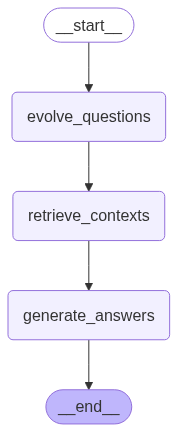

In [65]:
compiled_graph

In [66]:
# -------------------------------
# 🚀 Ejecutar el grafo
# -------------------------------
initial_state = {"documents": docs}
final_state = compiled_graph.invoke(initial_state)

In [ ]:
# -------------------------------
# ✅ Resultado
# -------------------------------
from pprint import pprint

print("\n📌 Evolved Questions:")
pprint(final_state["evolved_questions"])

print("\n📌 Contexts:")
pprint(final_state["contexts"])

print("\n📌 Answers:")
pprint(final_state["answers"])


📌 Evolved Questions:
[{'evolution_type': 'multi-context',
  'evolved_question': '1. What are the key components outlined in Volume 3 of '
                      'the Federal Student Aid Handbook concerning the '
                      'administration of Title IV student financial aid '
                      'programs in public universities versus private '
                      'institutions?',
  'id': 'd1da038f-7f1a-480c-8aeb-03d9a32fe51b',
  'original_question': '1. What are the key components discussed in Volume 3 '
                       'of the Federal Student Aid Handbook regarding the '
                       'administration of Title IV student financial aid '
                       'programs?'},
 {'evolution_type': 'reasoning',
  'evolved_question': 'How does Volume 3 clarify the meanings of terms like '
                      '"school," "we," and "you," and what reasoning does it '
                      'provide for their specific usage within the Federal '
                     

In [76]:
import pandas as pd

# Asegúrate de tener esto al final de tu script
questions = final_state["evolved_questions"]
contexts = final_state["contexts"]
answers = final_state["answers"]

# Convertir a dicts indexados por ID
ctx_dict = {c["id"]: c["contexts"] for c in contexts}
ans_dict = {a["id"]: a["answer"] for a in answers}

# Combinar todo en una lista de filas
rows = []
for q in questions:
    qid = q["id"]
    rows.append({
        "id": qid,
        "original_question": q["original_question"],
        "evolved_question": q["evolved_question"],
        "evolution_type": q["evolution_type"],
        "contexts": "\n\n".join(ctx_dict.get(qid, [])),
        "answer": ans_dict.get(qid, "")
    })

# Crear el DataFrame
df = pd.DataFrame(rows)

# Mostrarlo o exportarlo
print(df.columns.tolist())
# df.to_csv("synthetic_rag_dataset.csv", index=False)

['id', 'original_question', 'evolved_question', 'evolution_type', 'contexts', 'answer']


In [68]:
# -------------------------------
# 🛠️ LangSmith Instrumentation
# -------------------------------

from langsmith import Client

client = Client()

dataset_name = "Loan Synthetic Data Without RAGAS"

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Loan Synthetic Data Using LangGraph Agent Graph instead of RAGAS"
)

In [77]:
for data_row in df.iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["evolved_question"]
      },
      outputs={
          "answer": data_row[1]["answer"]
      },
      metadata={
          "context": data_row[1]["contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

In [81]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

In [82]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

In [83]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain.schema import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [84]:
eval_llm = ChatOpenAI(model="gpt-4.1")

In [85]:
from langsmith.evaluation import LangChainStringEvaluator, evaluate

qa_evaluator = LangChainStringEvaluator("qa", config={"llm" : eval_llm})

labeled_helpfulness_evaluator = LangChainStringEvaluator(
    "labeled_criteria",
    config={
        "criteria": {
            "helpfulness": (
                "Is this submission helpful to the user,"
                " taking into account the correct reference answer?"
            )
        },
        "llm" : eval_llm
    },
    prepare_data=lambda run, example: {
        "prediction": run.outputs["output"],
        "reference": example.outputs["answer"],
        "input": example.inputs["question"],
    }
)

empathy_evaluator = LangChainStringEvaluator(
    "criteria",
    config={
        "criteria": {
            "empathy": "Is this response empathetic? Does it make the user feel like they are being heard?",
        },
        "llm" : eval_llm
    }
)

In [86]:
evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        empathy_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'damp-potato-54' at:
https://smith.langchain.com/o/c21c7da9-346c-4a28-b19c-bb6d2faffe60/datasets/242f4845-958d-48e8-8293-fe40833ef32d/compare?selectedSessions=226d3c48-82d5-463f-a5c2-e4593336aa90




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.empathy,execution_time,example_id,id
0,3. How do different educational institutions h...,Different educational institutions may establi...,None,Different educational institutions handle defi...,1,1,0,5.693892,d7c0af9d-57b2-4380-8446-9328f597d2f4,aa5ba5df-f799-4c66-8ddd-85d63fbf4f56
1,2. How do academic year definitions vary betwe...,"Based on the provided context, the academic ye...",None,Academic year definitions vary between clock-h...,1,1,0,9.962769,3ed0816b-bf64-42b8-9203-57c9ffb118f5,5e9b68f6-cc96-4bae-ae02-e6ba8337569c
2,How does a school establish the academic year ...,A school may have different academic years for...,None,"Under Title IV guidelines, a school establishe...",1,0,0,1.978393,f6929830-d6a1-4086-b966-b97a817aea05,eda5301b-4ebc-4191-a85f-a5f0bcd4170c
3,3. How do the cost of attendance and disbursem...,The volume discusses that determining a studen...,None,The cost of attendance (COA) and disbursement ...,1,1,0,3.538791,6bcdafde-8e8e-44b1-a571-95449ac282ec,51e721a9-3413-4e01-afb2-e51fbe60d406
4,How does Volume 3 clarify the meanings of term...,Volume 3 clarifies the meanings of terms by sp...,None,Volume 3 of the Federal Student Aid (FSA) Hand...,1,1,0,2.768427,dd946648-63b0-4dbb-87d4-7de3329f8315,a6bce99f-f69a-425f-b7b5-88637c12fe65
5,1. What are the key components outlined in Vol...,I don't know.,None,Volume 3 of the Federal Student Aid (FSA) Hand...,0,0,0,1.388814,10869edd-b3bb-4577-aaba-a4f0b2ae8d1f,dc3f3e8a-b399-484b-9c7d-746f0e85c377


In [87]:
# -------------------------------
# 🚀 Dope-ifying Our Application
# -------------------------------

EMPATHY_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

You must answer the question using empathy and kindness, and make sure the user feels heard.

Context: {context}
Question: {question}
"""

empathy_rag_prompt = ChatPromptTemplate.from_template(EMPATHY_RAG_PROMPT)

In [88]:
rag_documents = docs

In [89]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

In [90]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

In [91]:
vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Loan Data for RAG"
)

In [92]:
retriever = vectorstore.as_retriever()

In [93]:
empathy_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | empathy_rag_prompt | llm | StrOutputParser()
)

In [94]:
evaluate(
    empathy_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        empathy_evaluator
    ],
    metadata={"revision_id": "empathy_rag_chain"},
)

View the evaluation results for experiment: 'puzzled-hill-97' at:
https://smith.langchain.com/o/c21c7da9-346c-4a28-b19c-bb6d2faffe60/datasets/242f4845-958d-48e8-8293-fe40833ef32d/compare?selectedSessions=971c2548-4f43-4c9c-b6b5-1b64f45c5f86




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.empathy,execution_time,example_id,id
0,3. How do different educational institutions h...,Thank you for your thoughtful question. Based ...,None,Different educational institutions handle defi...,1,0,1,5.116632,d7c0af9d-57b2-4380-8446-9328f597d2f4,f4218a3f-8b76-4a72-aff5-87591e9de84a
1,2. How do academic year definitions vary betwe...,Thank you for your thoughtful question. It’s c...,None,Academic year definitions vary between clock-h...,1,0,1,5.878288,3ed0816b-bf64-42b8-9203-57c9ffb118f5,49be7cdd-ff1d-4e97-9d79-473a13b2c079
2,How does a school establish the academic year ...,Thank you for your thoughtful question. Based ...,None,"Under Title IV guidelines, a school establishe...",1,0,1,6.282048,f6929830-d6a1-4086-b966-b97a817aea05,7de76151-a7af-4a60-b65a-bea9757a5600
3,3. How do the cost of attendance and disbursem...,Thank you for your thoughtful question. Based ...,None,The cost of attendance (COA) and disbursement ...,1,1,1,9.054497,6bcdafde-8e8e-44b1-a571-95449ac282ec,04126a59-d1ca-4ef5-b0ff-b9dbbd62f0da
4,How does Volume 3 clarify the meanings of term...,Thank you for your thoughtful question. Based ...,None,Volume 3 of the Federal Student Aid (FSA) Hand...,1,1,1,11.974727,dd946648-63b0-4dbb-87d4-7de3329f8315,882500be-d1b4-4399-950f-df43adc75b12
5,1. What are the key components outlined in Vol...,Thank you for your question. I understand that...,None,Volume 3 of the Federal Student Aid (FSA) Hand...,1,0,1,5.570028,10869edd-b3bb-4577-aaba-a4f0b2ae8d1f,043c2b1b-b3e4-49f9-ac64-49a9a9b9b0ac
